## Text Preprocessing

In [6]:
# Import Required Libraries

import re
import string
import pandas as pd
import nltk

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize

# Download NLTK Resources

nltk.download("punkt")
nltk.download("stopwords")
nltk.download("wordnet")
nltk.download("omw-1.4")

df = pd.read_csv("data/merged_news.csv") #Load Dataset

# Initialize Stopwords and Lemmatizer

stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()

# Create Combined Text

df["content"] = (
    df["title"].fillna("") + " " +
    df["text"].fillna("")
)

# Define the Preprocessing Function

def preprocess_text(text):

    # Handle missing values
    if pd.isna(text):
        return ""

    # Convert to string
    text = str(text)

    # Convert to lowercase
    text = text.lower()

    # Remove HTML tags
    text = re.sub(r"<.*?>", "", text)

    # Remove URLs
    text = re.sub(r"http\S+|www\S+", "", text)

    # Remove numbers
    text = re.sub(r"\d+", "", text)

    # Remove punctuation
    text = text.translate(
        str.maketrans("", "", string.punctuation)
    )

    # Remove extra whitespaces
    text = re.sub(r"\s+", " ", text).strip()

    # Tokenization
    tokens = word_tokenize(text)

    # Remove stopwords
    tokens = [
        word
        for word in tokens
        if word not in stop_words
    ]

    # Lemmatization
    tokens = [
        lemmatizer.lemmatize(word)
        for word in tokens
    ]

    # Join words
    return " ".join(tokens)

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\KIIT\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\KIIT\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\KIIT\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\KIIT\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


In [7]:
df["clean_text"] = df["content"].apply(preprocess_text)

In [8]:
print("Original:\n")
print(df.loc[0, "content"])

print("\n" + "-" * 80 + "\n")

print("Cleaned:\n")
print(df.loc[0, "clean_text"])

Original:

WOW! LEFTIST LIBRARIAN REJECTS Shipment Of Children’s Books Donated By Melania Trump…Her Reason For Rejecting The Books Is DISGUSTING! A school librarian in Cambridge, Massachusetts, rejected a shipment of books that were donated by first lady Melania Trump, according to CBS Boston.#HBFamilyReading: "Dear Mrs. Trump": @reflectlibrary says, Thanks but no thanks to the First Lady + Dr. Seuss  https://t.co/98SUPkjUN6 pic.twitter.com/3t6U6vvwPI  The Horn Book (@HornBook) September 26, 2017CBS Boston on Wednesday reported that Liz Phipps Soeiro of Cambridgeport Elementary School turned down the works Trump intended to send.The White House chose one school in all 50 states to receive a package of 10 books authored by children s literary author Dr. Seuss.The initiative was meant to promote education and childhood literacy as part of National Read A Book Day.Soeiro on Tuesday penned an editorial for the Horn Book s Family Reading blog explaining why her school did not need the donat

In [9]:
df.to_csv(
    "data/preprocessed_news.csv",
    index=False
)

## TF-IDF Feature Engineering

In [10]:
## Train–Validation–Test Split

In [11]:
from sklearn.model_selection import train_test_split

# Features and labels
X = df["clean_text"]
y = df["label"]

# First split: 80% train+validation, 20% test
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=42
)

# Second split: 70% train, 10% validation
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val,
    y_train_val,
    test_size=0.125,      # 0.125 × 80% = 10%
    stratify=y_train_val,
    random_state=42
)

In [12]:
## TF-IDF Vectorizer

In [13]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2),
    min_df=5,
    max_df=0.8
)

In [14]:
## Fit Only on the Training Set

In [15]:
X_train_tfidf = tfidf.fit_transform(X_train)

In [16]:
X_val_tfidf = tfidf.transform(X_val)

X_test_tfidf = tfidf.transform(X_test)

In [17]:
print(X_train_tfidf.shape)

(31282, 5000)


In [18]:
import joblib #Save the Vectorizer

joblib.dump(
    tfidf,
    "models/tfidf_vectorizer.pkl"
)

['models/tfidf_vectorizer.pkl']

## Logistic Regression

In [19]:
## Import & Create the Model

In [20]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(
    C=1.0,
    max_iter=1000,
    random_state=42,
    solver="liblinear"
)

In [21]:
## Train the Model

In [22]:
model.fit(X_train_tfidf, y_train)

LogisticRegression(max_iter=1000, random_state=42, solver='liblinear')

In [23]:
## Analyze the Model

In [24]:
val_predictions = model.predict(X_val_tfidf)

val_probabilities = model.predict_proba(X_val_tfidf)

test_predictions = model.predict(X_test_tfidf)

test_probabilities = model.predict_proba(X_test_tfidf)

print(model.coef_.shape)

(1, 5000)


In [25]:
## Save the Model

In [26]:
import joblib

joblib.dump(
    model,
    "models/logistic_regression.pkl"
)

['models/logistic_regression.pkl']

In [27]:
model = joblib.load(
    "models/logistic_regression.pkl"
)

In [28]:
## Predict on a New Article

In [29]:
news = """
Scientists discover a new vaccine that significantly reduces disease transmission.
"""

clean_news = preprocess_text(news)

vector = tfidf.transform([clean_news])

prediction = model.predict(vector)[0]

probability = model.predict_proba(vector)[0]


if prediction == 1:
    print("Real News")
else:
    print("Fake News")

print(f"Probability: {probability}")

Fake News
Probability: [0.73040066 0.26959934]


## Training Pipeline and Model Saving

In [30]:
## Import Required Libraries

In [31]:
import joblib
import pandas as pd

from sklearn.model_selection import train_test_split

from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.linear_model import LogisticRegression

In [32]:
## Load the Dataset

In [33]:
df = pd.read_csv("data/preprocessed_news.csv")

In [34]:
df["clean_text"] = df["clean_text"].fillna("")

In [35]:
## Split the Dataset

In [36]:
X = df["clean_text"]
y = df["label"]

from sklearn.model_selection import train_test_split

X_train_val, X_test, y_train_val, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=42
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_val,
    y_train_val,
    test_size=0.125,
    stratify=y_train_val,
    random_state=42
)

In [37]:
## Initialize TF-IDF

In [38]:
tfidf = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1,2),
    min_df=5,
    max_df=0.8
)

X_train_tfidf = tfidf.fit_transform(X_train) # Fit TF-IDF on Training Data

In [39]:
## Transform Validation & Test Data

In [40]:
X_val_tfidf = tfidf.transform(X_val)

In [41]:
X_test_tfidf = tfidf.transform(X_test)

In [42]:
## Initialize Logistic Regression

In [43]:
model = LogisticRegression(

    C=1,

    max_iter=1000,

    random_state=42,

    solver="liblinear"

)

In [44]:
## Train the Model

In [45]:
model.fit(

    X_train_tfidf,

    y_train

)

LogisticRegression(C=1, max_iter=1000, random_state=42, solver='liblinear')

In [46]:
## Validate and Test the Model

In [47]:
val_predictions = model.predict(X_val_tfidf)

val_predictions = model.predict(X_val_tfidf)

print("Validation completed successfully.")

Validation completed successfully.


In [48]:
y_pred = model.predict(X_test_tfidf)

y_prob = model.predict_proba(X_test_tfidf)[:,1]

In [49]:
## Save TF-IDF and Logistic Regression

In [50]:
import os
import joblib

os.makedirs("models", exist_ok=True)

joblib.dump(model, "models/logistic_regression.pkl")

joblib.dump(tfidf, "models/tfidf_vectorizer.pkl")

print("Model and TF-IDF Vectorizer saved successfully.")

Model and TF-IDF Vectorizer saved successfully.


In [51]:
## Loading Saved Objects

In [52]:
import joblib

tfidf = joblib.load(

    "models/tfidf_vectorizer.pkl"

)

model = joblib.load(

    "models/logistic_regression.pkl"

)

In [53]:
## Predicting a New News Article

In [54]:
news = """

NASA discovers evidence of water on Mars.

Scientists confirmed the discovery after analysing
satellite images.

"""

clean_news = preprocess_text(news)

vector = tfidf.transform(

    [clean_news]

)

prediction = model.predict(

    vector

)

probability = model.predict_proba(

    vector

)

if prediction[0]==1:

    print("Real News")

else:

    print("Fake News")

print(

    probability

)

Fake News
[[0.97390392 0.02609608]]


## Model Evaluation – Evaluation Metrics, ROC Curve, Confusion Matrix

In [55]:
## Import Required Libraries

In [56]:
import joblib
import matplotlib.pyplot as plt
import pandas as pd

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    ConfusionMatrixDisplay
)

In [57]:
## Load Saved Objects

In [58]:
model = joblib.load(
    "models/logistic_regression.pkl"
)

tfidf = joblib.load(
    "models/tfidf_vectorizer.pkl"
)

In [59]:
## Transform the Test Data

In [60]:
X_test_tfidf = tfidf.transform(X_test)

In [61]:
## Generate Predictions

In [62]:
y_pred = model.predict(X_test_tfidf)

y_prob = model.predict_proba(X_test_tfidf)[:,1]

In [63]:
## Confusion Matrix

In [64]:
cm = confusion_matrix(
    y_test,
    y_pred
)

print(cm)

[[4626   70]
 [  45 4197]]


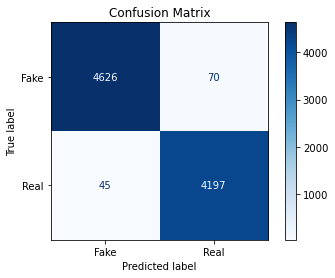

In [65]:
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Fake","Real"]
)

disp.plot(
    cmap="Blues"
)

plt.title("Confusion Matrix")

plt.savefig(
    "outputs/confusion_matrix.png"
)

plt.show()

In [66]:
## Compute Accuracy

In [67]:
accuracy = accuracy_score(
    y_test,
    y_pred
)

print(accuracy)

0.9871335869321995


In [68]:
## Compute Precision

In [69]:
precision = precision_score(
    y_test,
    y_pred
)

print(precision)

0.9835950316381533


In [70]:
## Compute Recall

In [71]:
recall = recall_score(
    y_test,
    y_pred
)

print(recall)

0.9893917963224894


In [72]:
## Compute F1 Score

In [73]:
f1 = f1_score(
    y_test,
    y_pred
)

print(f1)

0.986484898342931


In [74]:
## ROC Curve

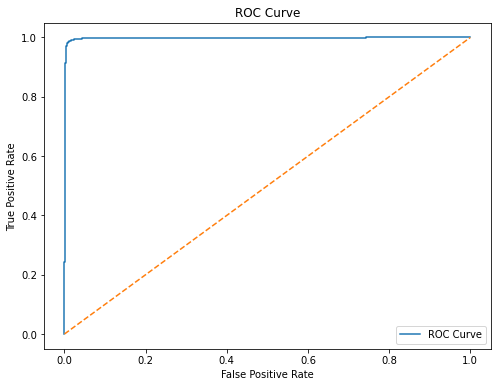

In [75]:
fpr, tpr, thresholds = roc_curve(
    y_test,
    y_prob
)

plt.figure(figsize=(8,6))

plt.plot(
    fpr,
    tpr,
    label="ROC Curve"
)

plt.plot(
    [0,1],
    [0,1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend()

plt.savefig(
    "outputs/roc_curve.png"
)

plt.show()

In [76]:
## Compute AUC

In [77]:
auc = roc_auc_score(
    y_test,
    y_prob
)

print(auc)

0.9983485297909201


In [78]:
## Classification Report

In [79]:
print(
    classification_report(
        y_test,
        y_pred,
        target_names=["Fake","Real"]
    )
)

              precision    recall  f1-score   support

        Fake       0.99      0.99      0.99      4696
        Real       0.98      0.99      0.99      4242

    accuracy                           0.99      8938
   macro avg       0.99      0.99      0.99      8938
weighted avg       0.99      0.99      0.99      8938



In [80]:
## Save Metrics

In [81]:
with open(
    "outputs/metrics.txt",
    "w"
) as f:

    f.write(
        f"Accuracy : {accuracy:.4f}\n"
    )

    f.write(
        f"Precision : {precision:.4f}\n"
    )

    f.write(
        f"Recall : {recall:.4f}\n"
    )

    f.write(
        f"F1 Score : {f1:.4f}\n"
    )

    f.write(
        f"AUC : {auc:.4f}\n"
    )

In [82]:
## Error Analysis

In [83]:
results = pd.DataFrame({
    "Text": X_test.reset_index(drop=True),
    "Actual": y_test.reset_index(drop=True),
    "Predicted": y_pred
})

errors = results[
    results["Actual"] != results["Predicted"]
]

print(f"Total Errors: {len(errors)}")

errors.to_csv(
    "outputs/misclassified_articles.csv",
    index=False
)

Total Errors: 115
